In [1]:
import sys
import pickle
import asyncio
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from sklearn import model_selection, decomposition, metrics, linear_model
import matplotlib.pyplot as plt
from pathlib import Path
from importlib.metadata import version                                                  # Вывод информации о библиотеках Python
from tqdm.asyncio import tqdm as async_tqdm                                             # Отслежевание прогресса при асинхронных запросах
from lib import clickhouse_tools as ch
from lib import data_tools as dt
import plotly.graph_objects as go                                                       # Интерактивные 3d графики   

In [2]:
print(f"Python {sys.version}")
libs = ["clickhouse_connect", "numpy", "pandas", "polars", "seaborn", "matplotlib", "plotly", "scikit-learn", "scipy", "tqdm"]
for lib in libs:
    print(lib, version(lib))

Python 3.14.8 | packaged by conda-forge | (main, Oct  7 2026, 00:23:19) [GCC 15.3.0]
clickhouse_connect 1.10.0
numpy 2.5.3
pandas 3.0.6
polars 2.0.0
seaborn 0.13.2
matplotlib 3.11.2
plotly 7.1.0
scikit-learn 1.9.1
scipy 1.18.1
tqdm 4.70.1


In [3]:
config = ch.Config("../.env")
run_date = "2026-10-09"
step_folder = Path(f"../steps/3/{run_date}")
prev_step_folder = Path(f"../steps/2/2026-10-08")
step_folder.mkdir(parents=True, exist_ok=True)
parameters = {
    "RANDOM_STATE"                    : 9,                             #  Фиксированное состояние генератора случайных чисел (для воспроизводимости)
    "EXCLUDED_CHROMOSOMES"            : ["chrX","chrY","chrM"],        #  Черный список хромосом (фильтр №1)
    "RATE_TOTAL_THRESHOLD"            : 0.8,                           #  Фильтр №2  
    "RATE_CLEAN_DEEP_THRESHOLD"       : 0.5,                           #  Фильтр №3
    "MEDIAN_DEPTH_MIN_THRESHOLD"      : 10,                            #  Фильтр №4 нижняя граница 
    "MEDIAN_DEPTH_MAX_THRESHOLD"      : 100,                           #  Фильтр №4 верхняя граница  
    "STD_BETA_THRESHOLD"              : 20,                            #  Фильтр №5  
    "TOTAL_MIN_AVG_DEPTH"             : 10,                            #  Фильтр качества образцов
    "SSB_QUANTILE_THRESHOLD"          : 0.95,                          #  Фильтр №6 верхняя граница
    "SSW_QUANTILE_THRESHOLD"          : 0.05,                          #  Фильтр №6 нижняя граница
    "MAX_CONCURRENT_QUERIES"          : 4,                             #  Кол-во одновременных запросов к БД
    "IMPUTE_WINDOW_SIZE"              : 500                            #  Размер окна импутации (восстановления) данных
}

In [4]:
episign_hg38 = pd.read_csv("../data/episign_selected_hg38.bed",header = None, sep="\t").iloc[:,[0,1]]
episign_hg38.columns = ["chr","pos"]
episign_hg38["pos"] -= 1
episign_hg38

,chr,pos
0,chr14,30874076
1,chr1,151165199
2,chr21,34886943
3,chr14,24316281
4,chr19,49340369
...,...,...
392,chr17,49992989
393,chr1,38029378
394,chr12,56223945
395,chr17,76528288


In [5]:
with open(prev_step_folder / 'pca_model.pkl','rb') as f:
    pca = pickle.load(f)
    
locus_df = pl.DataFrame({"data": pca.feature_names_in_})

# Split into multiple columns using str.split
locus_df = locus_df.with_columns(
    pl.col("data").str.split('_').list.get(0).alias("chr"),
    pl.col("data").str.split('_').list.get(1).alias("pos")
).drop("data").with_columns(
    pl.col("pos").cast(pl.UInt32)
)
locus_df_pd = locus_df.to_pandas()
locus_df_pd

,chr,pos
0,chr1,21784097
1,chr1,21784104
2,chr1,21784141
3,chr1,21784150
4,chr1,21784204
...,...,...
4590,chr22,44273391
4591,chr22,44390774
4592,chr22,50613881
4593,chr22,50697381


Отфильтровано 242 локусов


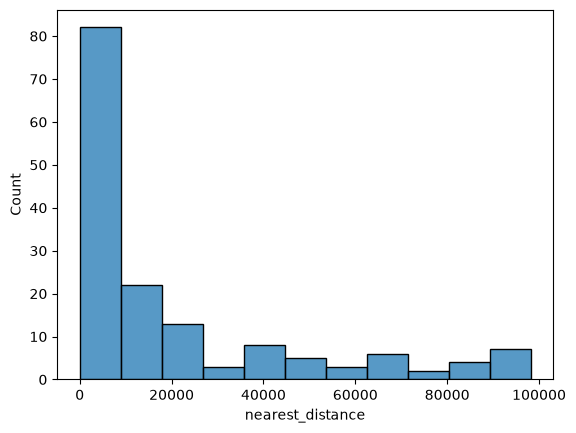

In [6]:
result = dt.find_nearest_kdtree(episign_hg38, locus_df_pd, pos_col="pos")
less_1mbp = result[result['nearest_distance'] < 10**5]
print(f"Отфильтровано {len(result.index) - len(less_1mbp.index)} локусов")
sns.histplot(data=less_1mbp, x = 'nearest_distance')
plt.savefig(step_folder / "episign_dist.png")

In [7]:
semaphore = asyncio.Semaphore(parameters['MAX_CONCURRENT_QUERIES'])
batches = ch.get_batches(pl.from_pandas(episign_hg38), batch_size = 10000)    
to_split = pl.read_csv("../steps/1/2026-10-08/total_info.csv", schema_overrides = {"btk_id": pl.String}) 
requests = [ch.task(ch.get_methylation_data, semaphore, batch, i, to_split["btk_id"].to_list(), config) for i, batch in batches]
results = await async_tqdm.gather(*requests)
list_res = [df for _, df in results if df is not None]
for i in range(1,len(list_res)):
    list_res[i] = list_res[i].drop("btk_id")# Удалим столбец с идентификаторами из всех порций кроме первой
data_episign_raw = pl.concat(list_res,how="horizontal")
data_episign_raw.write_csv(step_folder / "data_episign_raw.csv")
data_episign_imputed = dt.impute_meth_data(data_episign_raw, config.get_client(), parameters)
data_episign_imputed.to_csv(step_folder / "data_episign_imputed.csv")
data_episign_imputed

100%|██████████| 22/22 [00:00<00:00, 29.95it/s]


Total scanned: 43382
Scanned: 10000
Scanned: 20000
Scanned: 30000
Scanned: 40000
Num of missing: 20


,btk_id,chr14_20622723,chr14_24316281,chr14_30874076,chr14_50785943,chr14_57391664,chr14_99174679,chr14_100165460,chr14_102545850,chr14_102927632,...,chr8_140509170,chr8_143125843,chr8_143764139,chr22_20430254,chr22_37803872,chr22_39318282,chr22_39521827,chr22_41096002,chr22_45309152,chr22_49826105
0,000007027610,0.77,0.85,0.71,0.33,0.10,0.96,0.61,0.76,0.79,...,0.61,0.71,0.30,0.04,1.00,0.05,0.37,0.53,0.46,0.18
1,000007028770,0.67,1.00,0.25,0.40,0.29,0.92,0.25,0.50,0.64,...,0.67,0.92,0.25,0.00,1.00,0.25,0.46,0.53,0.28,0.50
2,000007028810,0.74,1.00,0.57,0.45,0.23,1.00,0.80,0.35,0.58,...,0.77,0.92,0.30,0.18,1.00,0.05,0.50,0.67,0.68,0.27
3,000007028880,0.89,1.00,0.20,0.22,0.36,1.00,0.88,0.78,1.00,...,0.94,0.73,0.13,0.00,1.00,0.19,0.17,0.53,0.21,0.21
4,000007029030,1.00,1.00,0.50,0.29,0.15,1.00,0.88,0.69,0.64,...,1.00,0.85,0.11,0.24,0.94,0.10,0.40,0.25,0.67,0.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,000027007900,0.92,0.87,0.44,0.25,0.11,0.82,0.67,0.55,0.91,...,0.60,0.80,0.12,0.07,0.95,0.08,0.25,0.64,0.62,0.17
105,000027007990,0.92,0.92,0.44,0.14,0.38,0.89,0.67,0.54,0.93,...,0.72,1.00,0.22,0.23,1.00,0.12,0.33,0.50,0.33,0.17
106,000027008020,0.76,0.91,0.36,0.19,0.17,0.89,0.38,0.57,0.69,...,0.70,0.96,0.25,0.17,1.00,0.20,0.23,0.25,0.52,0.22
107,000027008050,0.82,1.00,0.32,0.33,0.18,1.00,0.42,0.71,0.88,...,0.58,1.00,0.62,0.06,1.00,0.07,0.58,0.55,0.58,0.39


In [8]:
X_episign = data_episign_imputed.drop(columns="btk_id")
X_episign.to_csv(step_folder / "X_episign.csv")
y_episign= to_split["group"].to_numpy()
y_label_episign = to_split["id"].to_numpy()
y_btk_episign = to_split["btk_id"].to_numpy()

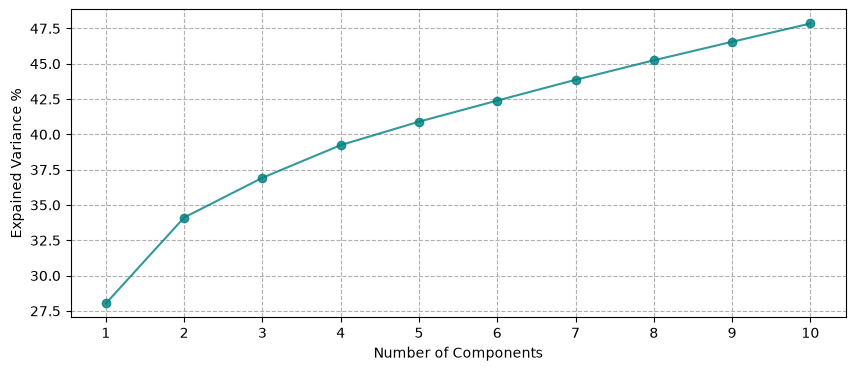

In [9]:
pca_episign = decomposition.PCA(n_components = 10, random_state = parameters['RANDOM_STATE'])
X_transformed_episign = pca_episign.fit_transform(X_episign)
fig = plt.figure(figsize = (10,4))
plt.plot(np.arange(1, X_transformed_episign.shape[1]+1),100 * np.cumsum(pca_episign.explained_variance_ratio_), marker = 'o',
         color = 'teal', alpha = .8)
plt.xticks(np.arange(1, X_transformed_episign.shape[1]+1),np.arange(1, X_transformed_episign.shape[1]+1))
plt.xlabel('Number of Components')
plt.ylabel('Expained Variance %')
plt.grid(linestyle = '--')
plt.savefig(step_folder / "scree_plot_episign.png")

In [10]:
X_transformed_episign_df = pd.DataFrame(X_transformed_episign, columns = [f'PC{i}' for i in range(1,11)])
X_transformed_episign_df["target"] = y_episign
X_transformed_episign_df["id"] = y_label_episign
X_transformed_episign_df["btk_id"] = y_btk_episign
X_transformed_episign_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,target,id,btk_id
0,1.427398,-1.169310,-0.482267,0.302772,-0.398676,-0.387064,0.688902,0.424775,-0.223729,0.108157,Kabuki,K7,000007027610
1,-0.170433,1.058446,-0.225472,0.028762,0.225387,0.374552,0.114794,-0.585044,0.083438,0.106134,Normal,N39,000007028770
2,0.255557,0.853014,-0.412294,0.024710,0.334811,0.124814,0.212487,-0.082994,-0.129992,-0.068859,Normal,N38,000007028810
3,0.306004,0.450719,0.079850,-0.267140,-0.794775,-0.385216,1.171485,-0.076639,-0.089928,-0.307873,Normal,N36,000007028880
4,0.879665,0.878921,0.384544,0.505509,-0.310393,0.105811,-0.053238,0.313694,-0.092189,0.109129,Normal,N35,000007029030


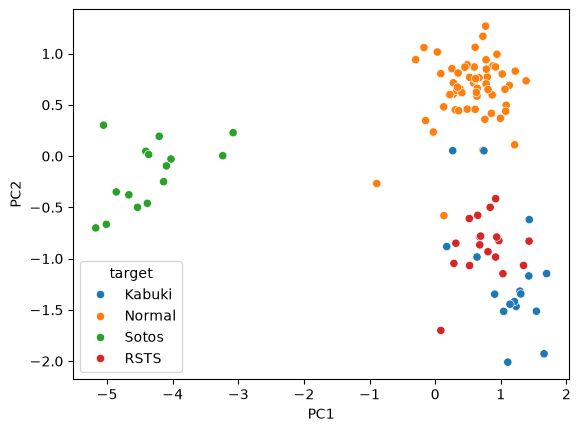

In [11]:
sns.scatterplot(data = X_transformed_episign_df, x ="PC1", y = "PC2",hue="target")
plt.savefig(step_folder / "2d_pca_episign.png",dpi = 300)

In [12]:
fig = go.Figure()
# Add traces for each category (for different colors)
for category in X_transformed_episign_df['target'].unique():
    df_cat = X_transformed_episign_df[X_transformed_episign_df['target'] == category]
    fig.add_trace(go.Scatter3d(
        x=df_cat['PC1'],
        y=df_cat['PC2'],
        z=df_cat['PC3'],
        mode='markers+text',
        name=category,
        text=df_cat['id'],
        textposition='top center',
        textfont=dict(size=10)
    ))

fig.update_layout(
    title='3D PCA',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)  # Initial camera angle
        )
    ),
    legend_title_text='Categories',
    width=800,
    height=800
)
fig.write_image(step_folder / "3d_pca_episign.png")
fig.show()

In [13]:
train_samples = pl.read_csv("../steps/1/2026-10-08/train_samples.csv", schema_overrides = {"btk_id": pl.String})
train_id = train_samples["btk_id"].to_list()
val_samples = pl.read_csv("../steps/1/2026-10-08/val_samples.csv", schema_overrides = {"btk_id": pl.String})
val_id = val_samples["btk_id"].to_list()

X_transformed_episign_train_df = X_transformed_episign_df.query("btk_id.isin(@train_id)")
X_transformed_episign_val_df = X_transformed_episign_df.query("btk_id.isin(@val_id)")

X_episign_train = X_transformed_episign_train_df.loc[:,X_transformed_episign_train_df.columns.str.startswith("PC")]
y_episign_train = X_transformed_episign_train_df["target"]
X_episign_val = X_transformed_episign_val_df.loc[:,X_transformed_episign_val_df.columns.str.startswith("PC")]
y_episign_val = X_transformed_episign_val_df["target"]

In [14]:
X_pca = X_episign_train[["PC1","PC2",'PC3']]
param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'newton-cg'],
        'max_iter': [500, 1000, 2000],
        'class_weight': [None, 'balanced']
    }

classifier = linear_model.LogisticRegression(
        max_iter=1000,
        random_state=parameters['RANDOM_STATE'],
        class_weight='balanced'     # Handle imbalanced classes if needed
    )
    
    # Step 4: Perform stratified k-fold cross-validation
cv_strategy = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=parameters['RANDOM_STATE'])

grid_search = model_selection.GridSearchCV(
        classifier, param_grid, 
        cv=cv_strategy,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=1
)
    
# Fit grid search
est = grid_search.fit(X_pca, y_episign_train)
best_model = grid_search.best_estimator_
    
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
    
y_pred = model_selection.cross_val_predict(best_model, X_pca, y_episign_train, cv=5)
    # Cross-validation scores
cv_scores = model_selection.cross_val_score(
        classifier, X_pca, y_episign_train, 
        cv=cv_strategy, 
        scoring='accuracy',
        n_jobs=-1  # Use all processors
    )
    
    # Get cross-validated predictions
y_pred = model_selection.cross_val_predict(
        classifier, X_pca, y_episign_train, 
        cv=cv_strategy, 
        n_jobs=-1
    )
    
results = {
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'X_pca': X_pca,
        'y_pred': y_pred,
        'classification_report': metrics.classification_report(y_episign_train, y_pred)
    }
print(f"\nClassification Report with Best Model:\n{results['classification_report']}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Best CV accuracy: 0.9715

Classification Report with Best Model:
              precision    recall  f1-score   support

      Kabuki       1.00      0.83      0.91        12
      Normal       0.97      0.95      0.96        41
        RSTS       0.81      1.00      0.90        13
       Sotos       1.00      1.00      1.00        10

    accuracy                           0.95        76
   macro avg       0.95      0.95      0.94        76
weighted avg       0.95      0.95      0.95        76



In [15]:
y_val_pred = best_model.predict(X_episign_val[["PC1","PC2","PC3"]])
print(f"\nClassification Report:\n{metrics.classification_report(y_episign_val, y_val_pred)}")


Classification Report:
              precision    recall  f1-score   support

      Kabuki       1.00      0.80      0.89         5
      Normal       1.00      1.00      1.00        18
        RSTS       0.83      1.00      0.91         5
       Sotos       1.00      1.00      1.00         5

    accuracy                           0.97        33
   macro avg       0.96      0.95      0.95        33
weighted avg       0.97      0.97      0.97        33



In [16]:
# Сохраним модели
with open(step_folder / 'pca_episign_model.pkl','wb') as f:
    pickle.dump(pca_episign,f)

with open(step_folder / 'logreg_episign_model.pkl','wb') as f:
    pickle.dump(results,f)